In [8]:
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU found! Go to Runtime -> Change runtime type -> T4 GPU")

GPU available: True
GPU name: Tesla T4


In [9]:
!pip install transformers accelerate -q

In [10]:
import os
import zipfile

ZIP_PATH     = 'brain-tumor-mri-dataset.zip'
EXTRACT_PATH = 'brain-tumor-mri-dataset'

if not os.path.exists(EXTRACT_PATH):
    print("Extracting... (takes about 1 min)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_PATH)
    print("Done!")
else:
    print("Already extracted, skipping")


for item in os.listdir(EXTRACT_PATH):
    print(item)

Already extracted, skipping
Testing
Training


In [11]:
def find_folder(base, name):
    for root, dirs, files in os.walk(base):
        for d in dirs:
            if d.lower() == name.lower():
                return os.path.join(root, d)
    return None

TRAIN_DIR = find_folder(EXTRACT_PATH, 'Training')
TEST_DIR  = find_folder(EXTRACT_PATH, 'Testing')

print("Train dir:", TRAIN_DIR)
print("Test dir: ", TEST_DIR)

print("\nTrain classes:", os.listdir(TRAIN_DIR))
print("Test classes: ", os.listdir(TEST_DIR))


print("\nImage counts per class (training):")
for cls in sorted(os.listdir(TRAIN_DIR)):
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"  {cls}: {n}")

Train dir: brain-tumor-mri-dataset/Training
Test dir:  brain-tumor-mri-dataset/Testing

Train classes: ['meningioma', 'pituitary', 'glioma', 'notumor']
Test classes:  ['meningioma', 'pituitary', 'glioma', 'notumor']

Image counts per class (training):
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400


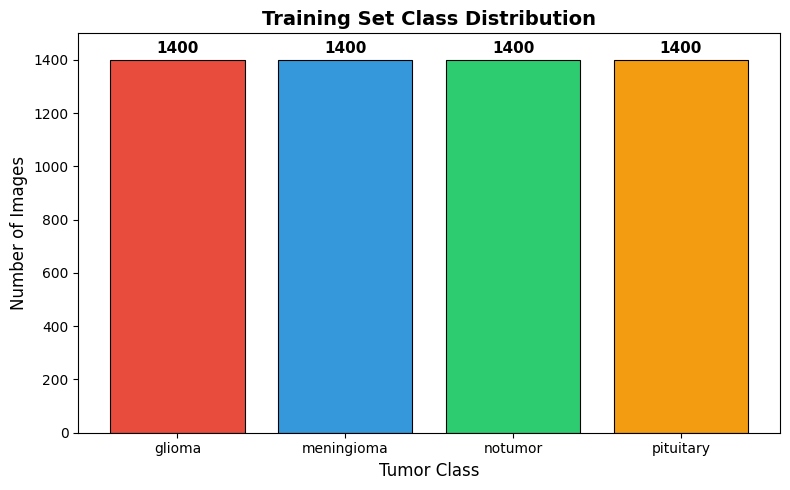

Chart saved as class_distribution.png


In [12]:
import matplotlib.pyplot as plt
import os

classes = sorted(os.listdir(TRAIN_DIR))
counts  = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(classes, counts, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'], edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Tumor Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_ylim(0, max(counts) + 100)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Chart saved as class_distribution.png")

In [13]:
import torch
import warnings
warnings.filterwarnings('ignore')
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from transformers import ViTImageProcessor

CHECKPOINT = 'google/vit-base-patch16-224'

image_processor = ViTImageProcessor.from_pretrained(CHECKPOINT)

class BrainTumorDataset(Dataset):
    def __init__(self, root, processor):
        self.data      = datasets.ImageFolder(root)
        self.processor = processor
        self.classes   = self.data.classes

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, label = self.data[idx]
        inputs = self.processor(
            images=image.convert('RGB'),
            return_tensors='pt'
        )
        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'labels': torch.tensor(label)
        }


train_dataset = BrainTumorDataset(TRAIN_DIR, image_processor)
test_dataset  = BrainTumorDataset(TEST_DIR,  image_processor)

CLASS_NAMES = train_dataset.classes
print("Classes:", CLASS_NAMES)
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train samples: 5600
Test samples:  1600


In [14]:
from transformers import ViTForImageClassification

NUM_CLASSES = 4

model = ViTForImageClassification.from_pretrained(
    CHECKPOINT,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True   # replaces the 1000-class ImageNet head with 4 classes
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(DEVICE)
print(f"Model loaded on {DEVICE}")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded on cuda


In [15]:
from transformers import get_linear_schedule_with_warmup

EPOCHS = 6
LR     = 2e-5

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Steps per epoch      : {len(train_loader)}")

Total training steps : 1050
Warmup steps         : 105
Steps per epoch      : 175


In [16]:
train_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(**batch)
        loss    = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | step {step+1}/{len(train_loader)} | loss {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch in test_loader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            preds   = outputs.logits.argmax(dim=-1)
            correct += (preds == batch['labels']).sum().item()
            total   += batch['labels'].size(0)

    acc = correct / total
    test_accuracies.append(acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  Test Acc: {acc:.4f}\n")

print("Training complete!")
print(f"Best accuracy: {max(test_accuracies):.4f}  (epoch {test_accuracies.index(max(test_accuracies))+1})")

  Epoch 1 | step 50/175 | loss 0.7584
  Epoch 1 | step 100/175 | loss 0.2911
  Epoch 1 | step 150/175 | loss 0.1819

Epoch 1/6  |  Loss: 0.5981  |  Test Acc: 0.9069

  Epoch 2 | step 50/175 | loss 0.1175
  Epoch 2 | step 100/175 | loss 0.1628
  Epoch 2 | step 150/175 | loss 0.0269

Epoch 2/6  |  Loss: 0.0860  |  Test Acc: 0.9463

  Epoch 3 | step 50/175 | loss 0.0191
  Epoch 3 | step 100/175 | loss 0.0215
  Epoch 3 | step 150/175 | loss 0.0350

Epoch 3/6  |  Loss: 0.0196  |  Test Acc: 0.9475

  Epoch 4 | step 50/175 | loss 0.0052
  Epoch 4 | step 100/175 | loss 0.0031
  Epoch 4 | step 150/175 | loss 0.0025

Epoch 4/6  |  Loss: 0.0065  |  Test Acc: 0.9487

  Epoch 5 | step 50/175 | loss 0.0033
  Epoch 5 | step 100/175 | loss 0.0035
  Epoch 5 | step 150/175 | loss 0.0088

Epoch 5/6  |  Loss: 0.0041  |  Test Acc: 0.9500

  Epoch 6 | step 50/175 | loss 0.0024
  Epoch 6 | step 100/175 | loss 0.0029
  Epoch 6 | step 150/175 | loss 0.0024

Epoch 6/6  |  Loss: 0.0034  |  Test Acc: 0.9500

Trai

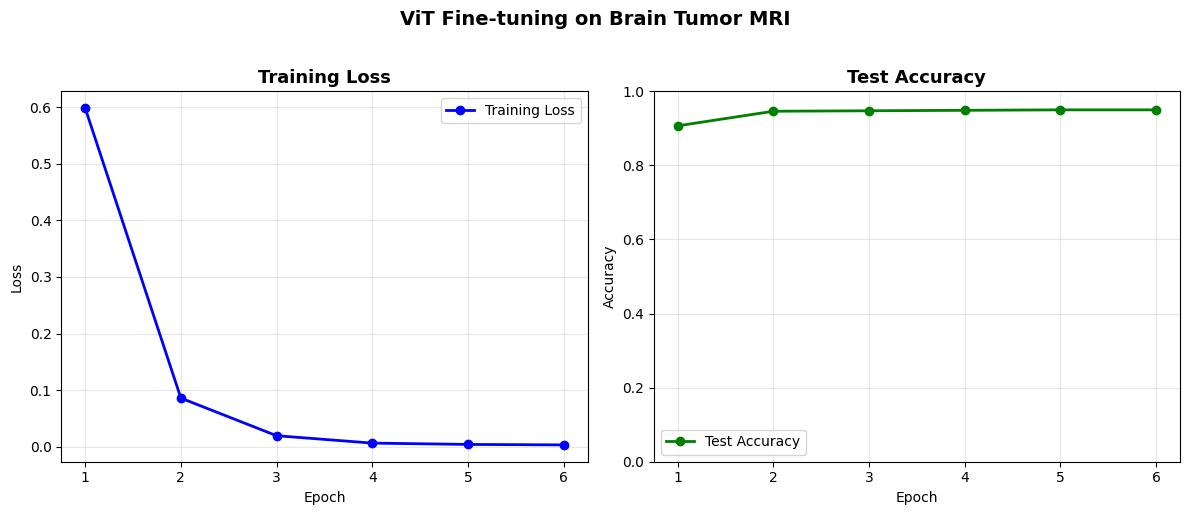

Final test accuracy: 0.9500


In [17]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epochs_range, train_losses, 'b-o', linewidth=2, markersize=6, label='Training Loss')
ax1.set_title('Training Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(epochs_range, test_accuracies, 'g-o', linewidth=2, markersize=6, label='Test Accuracy')
ax2.set_title('Test Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_xticks(epochs_range)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('ViT Fine-tuning on Brain Tumor MRI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final test accuracy: {test_accuracies[-1]:.4f}")

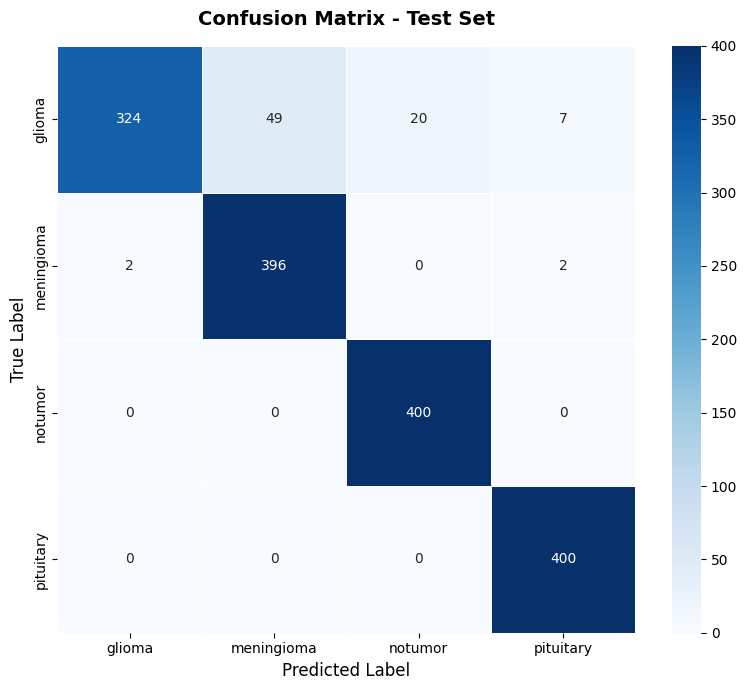


Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.89      0.99      0.94       400
     notumor       0.95      1.00      0.98       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds   = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

In [20]:
import os, json, torch

os.makedirs('artifacts', exist_ok=True)

torch.save(model.state_dict(), 'artifacts/vit_brain_tumor.pt')
print("Model weights saved.")

with open('artifacts/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)
print("Class names saved:", CLASS_NAMES)

Model weights saved.
Class names saved: ['glioma', 'meningioma', 'notumor', 'pituitary']
